In [1]:
from scipy.stats import chi2
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Log
from statsmodels.genmod.families.links import Identity
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *


In [2]:
df = pd.read_csv('dataset/donnerparty.txt', sep=' ')
print(df,'\n')

df['Sex'] = pd.Categorical(df['Sex'])
df['Status'] = pd.Categorical(df['Status'], categories=['Survived', 'Died'], ordered=True)

print(df.info())

    Age     Sex    Status
1    23    Male      Died
2    40  Female  Survived
3    40    Male  Survived
4    30    Male      Died
5    28    Male      Died
6    40    Male      Died
7    45  Female      Died
8    62    Male      Died
9    65    Male      Died
10   45  Female      Died
11   25  Female      Died
12   28    Male  Survived
13   28    Male      Died
14   23    Male      Died
15   22  Female  Survived
16   23  Female  Survived
17   28    Male  Survived
18   15  Female  Survived
19   47  Female      Died
20   57    Male      Died
21   20  Female  Survived
22   18    Male  Survived
23   25    Male      Died
24   60    Male      Died
25   25    Male  Survived
26   20    Male  Survived
27   32    Male  Survived
28   32  Female  Survived
29   24  Female  Survived
30   30    Male  Survived
31   15    Male      Died
32   50  Female      Died
33   21  Female  Survived
34   25    Male      Died
35   46    Male  Survived
36   32  Female  Survived
37   30    Male      Died
38   25    M

In [3]:
print(df.describe(),'\n')

for j in df.select_dtypes('category'):
    print(df[j].value_counts(),'\n')

             Age
count  45.000000
mean   31.800000
std    12.511086
min    15.000000
25%    24.000000
50%    28.000000
75%    40.000000
max    65.000000 

Sex
Male      30
Female    15
Name: count, dtype: int64 

Status
Died        25
Survived    20
Name: count, dtype: int64 



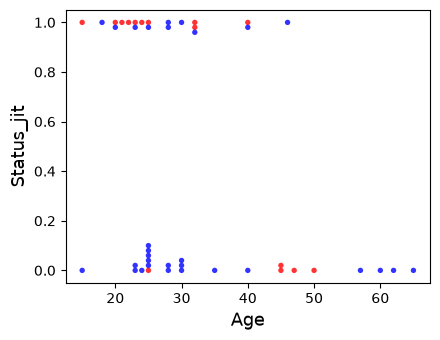

In [4]:
# Sort dataFrame by Age (young to old), and then Sex (female then male) and relabel rows
df_plot = df.copy()
df_plot = df_plot.sort_values(by=['Age', 'Sex']).reset_index(drop=True)

# Create a new variable called Survjit in dataframe
df_plot['Status_num'] = df_plot['Status'].map({'Survived': 1, 'Died': 0})
df_plot['Status_jit'] = df_plot['Status_num'].astype(float)

# create jitter sequence 
jit = df_plot.groupby(['Age', 'Status_num']).cumcount() * 0.02

#  Apply jitter to spread overlapping data points upward from 0 or downward from 1
df_plot.loc[df_plot['Status_num'] == 0, 'Status_jit'] += jit
df_plot.loc[df_plot['Status_num'] == 1, 'Status_jit'] -= jit

fig, ax = plt.subplots(figsize=(4.5, 3.5))
colors = ['red' if s == 'Female' else 'blue' for s in df_plot['Sex']]

ax.scatter(df_plot['Age'], df_plot['Status_jit'], c=colors, alpha=0.8, edgecolors='none', s=15)
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Status_jit', fontsize=13)

plt.tight_layout()
plt.show()

It seems that females and younger people have a higher probability of survivial.

In [5]:
fm = glm('Status ~ Age + Sex', df, family=Binomial()).fit()
print(fm.summary2(),'\n')

                       Results: Generalized linear model
Model:              GLM                                  Method:         IRLS   
Model Family:       Binomial                             AIC:            57.2563
Link Function:      Logit                                BIC:            62.6763
Dependent Variable: ['Status[Survived]', 'Status[Died]'] Log-Likelihood: -25.628
Date:               2026-09-15 10:53                     LL-Null:        -30.913
No. Observations:   45                                   Deviance:       51.256 
Df Model:           2                                    Pearson chi2:   44.4   
Df Residuals:       42                                   Scale:          1.0000 
------------------------------------------------------------------------------------
                  Coef.      Std.Err.        z        P>|z|       [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         3.2304       1.3870   

False
False 

0    0.460059
1    0.381855
2    0.303651
3    0.225447
4    0.147243
dtype: float64 

0    0.613028
1    0.594320
2    0.575335
3    0.556124
4    0.536744
dtype: float64 



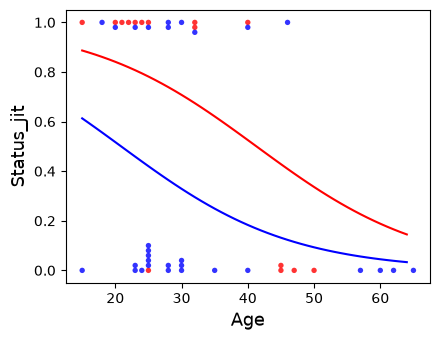

<Figure size 640x480 with 0 Axes>

In [6]:
ages = np.arange(15, 65)

# Build the new dataframes for prediction
pred_m_df = pd.DataFrame({'Age': ages, 'Sex': 'Male'})
pred_f_df = pd.DataFrame({'Age': ages, 'Sex': 'Female'})

# Compute predicted values on the response scale
pred_m = fm.predict(pred_m_df)
pred_f = fm.predict(pred_f_df)

# Compute predicted values on the link scale
pred_m_lin = fm.predict(pred_m_df, which='linear')
pred_f_lin = fm.predict(pred_f_df, which='linear')

# Check
print(expit(pred_m_lin).equals(pred_m))
print(expit(pred_f_lin).equals(pred_f),'\n')

print(pred_m_lin.head(5),'\n')
print(pred_m.head(5),'\n')

ax.plot(ages, pred_m, color="blue")
ax.plot(ages, pred_f, color="red")

plt.tight_layout()

from IPython.display import display
display(fig)

In [7]:
np.exp(0.0782*30)

np.float64(10.443711218652142)

In [8]:
np.exp(1.5973)

np.float64(4.939677274414974)

In [9]:
fm_full = glm('Status ~ Age * Sex', df, family=Binomial()).fit()
print(fm_full.summary2(),'\n')

                       Results: Generalized linear model
Model:              GLM                                  Method:         IRLS   
Model Family:       Binomial                             AIC:            55.3464
Link Function:      Logit                                BIC:            62.5730
Dependent Variable: ['Status[Survived]', 'Status[Died]'] Log-Likelihood: -23.673
Date:               2026-09-15 10:53                     LL-Null:        -30.913
No. Observations:   45                                   Deviance:       47.346 
Df Model:           3                                    Pearson chi2:   43.9   
Df Residuals:       41                                   Scale:          1.0000 
-----------------------------------------------------------------------------------
                     Coef.     Std.Err.       z       P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept            7.2464      3.2052    

In [10]:
anova_nested(fm, fm_full)

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
Model 1,42.0,51.256285,NaN,NaN,NaN
Model 2,41.0,47.346366,1.0,3.909918,0.048002


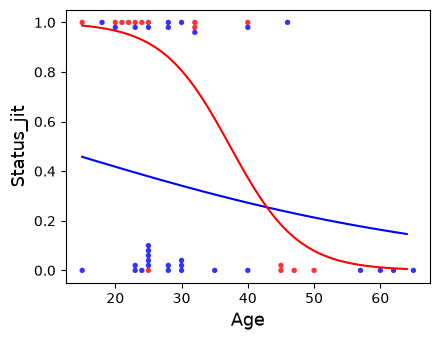

In [11]:
pred_m_full = fm_full.predict(pred_m_df)
pred_f_full = fm_full.predict(pred_f_df)

fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.scatter(df_plot['Age'], df_plot['Status_jit'], c=colors, alpha=0.8, edgecolors='none', s=15)
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Status_jit', fontsize=13)

ax.plot(ages, pred_m_full, color="blue")
ax.plot(ages, pred_f_full, color="red")

plt.tight_layout()
plt.show()

In [19]:
def bernoulli_deviance_residuals(y, mu):
    """Compute deviance residuals for Bernoulli observations (m_i = 1)."""
    y = np.asarray(y, dtype=float)
    mu = np.clip(np.asarray(mu, dtype=float), np.finfo(float).eps, 1 - np.finfo(float).eps)
    return np.where(
        y == 1,
        np.sqrt(2 * np.log(1 / mu)),
        -np.sqrt(2 * np.log(1 / (1 - mu)))
    )

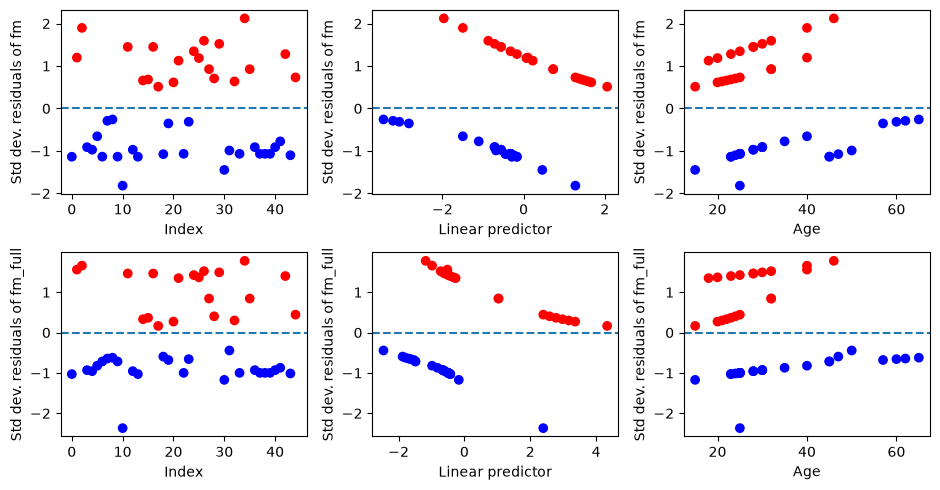

In [13]:
res_deviance_std = fm.resid_deviance / np.sqrt(1 - hat_diag(fm))
res_deviance_std_full = fm_full.resid_deviance / np.sqrt(1 - hat_diag(fm_full))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9.5, 5))

colors = ['red' if s > 0 else 'blue' for s in res_deviance_std]
colors_full = ['red' if s > 0 else 'blue' for s in res_deviance_std_full]

axes[0,0].scatter(range(len(df)), res_deviance_std, color=colors)
axes[0,0].axhline(0, linestyle='--')
axes[0,0].set_xlabel("Index")
axes[0,0].set_ylabel("Std dev. residuals of fm")

axes[0,1].scatter(fm.predict(df, which='linear'), res_deviance_std, color=colors)
axes[0,1].axhline(0, linestyle='--')
axes[0,1].set_xlabel("Linear predictor")
axes[0,1].set_ylabel("Std dev. residuals of fm")
    
axes[0,2].scatter(df['Age'], res_deviance_std, color=colors)
axes[0,2].axhline(0, linestyle='--')
axes[0,2].set_xlabel("Age")
axes[0,2].set_ylabel("Std dev. residuals of fm")

axes[1,0].scatter(range(len(df)), res_deviance_std_full, color=colors_full)
axes[1,0].axhline(0, linestyle='--')
axes[1,0].set_xlabel("Index")
axes[1,0].set_ylabel("Std dev. residuals of fm_full")

axes[1,1].scatter(fm_full.predict(df, which='linear'), res_deviance_std_full, color=colors_full)
axes[1,1].axhline(0, linestyle='--')
axes[1,1].set_xlabel("Linear predictor")
axes[1,1].set_ylabel("Std dev. residuals of fm_full")
    
axes[1,2].scatter(df['Age'], res_deviance_std_full, color=colors_full)
axes[1,2].axhline(0, linestyle='--')
axes[1,2].set_xlabel("Age")
axes[1,2].set_ylabel("Std dev. residuals of fm_full")

plt.tight_layout()
plt.show()